In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
print("Python environment is ready!")

Python environment is ready!


In [2]:
# Our target is the number of morning customers.
target = "Customers"
# Possible predictors:
features = ["Day", "Rain", "Temp", "Holiday"]
print("Target:", target)
print("Predictors:", features)

Target: Customers
Predictors: ['Day', 'Rain', 'Temp', 'Holiday']


In [3]:
# Create the coffee-shop dataset
data = {
"Day": ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun",
"Mon", "Tue", "Wed", "Thu", "Fri"],
"Rain": ["No", "No", "Yes", "No", "No", "No", "Yes",
"Yes", "No", "No", "Yes", "No"],
"Temp": [22, 24, 18, 26, 25, 23, 19, 17, 21, 23, 20, 27],
"Holiday": ["No", "No", "No", "No", "No", "No", "No",
"No", "Yes", "No", "No", "No"],
"Customers": [48, 55, 32, 61, 68, 82, 57, 35, 74, 52, 41, 71]
}
df = pd.DataFrame(data)
print(df)

    Day Rain  Temp Holiday  Customers
0   Mon   No    22      No         48
1   Tue   No    24      No         55
2   Wed  Yes    18      No         32
3   Thu   No    26      No         61
4   Fri   No    25      No         68
5   Sat   No    23      No         82
6   Sun  Yes    19      No         57
7   Mon  Yes    17      No         35
8   Tue   No    21     Yes         74
9   Wed   No    23      No         52
10  Thu  Yes    20      No         41
11  Fri   No    27      No         71


In [4]:
# Inspect the structure of the data
print("Shape:", df.shape)
print()
print("Column names:")
print(df.columns.tolist())
print()
print("Data types:")
print(df.dtypes)

Shape: (12, 5)

Column names:
['Day', 'Rain', 'Temp', 'Holiday', 'Customers']

Data types:
Day          object
Rain         object
Temp          int64
Holiday      object
Customers     int64
dtype: object


In [5]:
# Summary statistics for the numeric variables
print(df.describe())


            Temp  Customers
count  12.000000  12.000000
mean   22.083333  56.333333
std     3.175426  15.715270
min    17.000000  32.000000
25%    19.750000  46.250000
50%    22.500000  56.000000
75%    24.250000  68.750000
max    27.000000  82.000000


In [11]:
print(df["Customers"].describe())

count    12.000000
mean     56.333333
std      15.715270
min      32.000000
25%      46.250000
50%      56.000000
75%      68.750000
max      82.000000
Name: Customers, dtype: float64


In [13]:
print(df["Holiday"].describe())

count     12
unique     2
top       No
freq      11
Name: Holiday, dtype: object


In [14]:
print(df["Rain"].describe())

count     12
unique     2
top       No
freq       8
Name: Rain, dtype: object


In [15]:
print(df["Day"].describe())

count      12
unique      7
top       Mon
freq        2
Name: Day, dtype: object


In [7]:
# Check for missing values
print(df.isnull().sum())

Day          0
Rain         0
Temp         0
Holiday      0
Customers    0
dtype: int64


Day
Sat    82.0
Fri    69.5
Tue    64.5
Sun    57.0
Thu    51.0
Wed    42.0
Mon    41.5
Name: Customers, dtype: float64


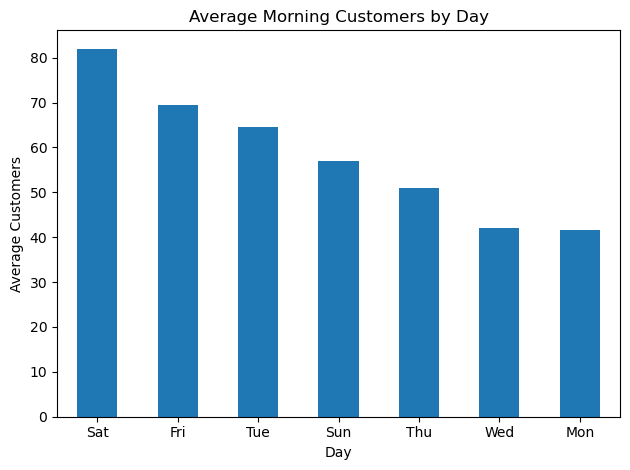

In [8]:
# Calculate average customers by day
day_summary = df.groupby("Day")["Customers"].mean().sort_values(ascending=False)
print(day_summary)
# Visualize the result
day_summary.plot(kind="bar")
plt.title("Average Morning Customers by Day")
plt.xlabel("Day")
plt.ylabel("Average Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Rain
No     63.875
Yes    41.250
Name: Customers, dtype: float64


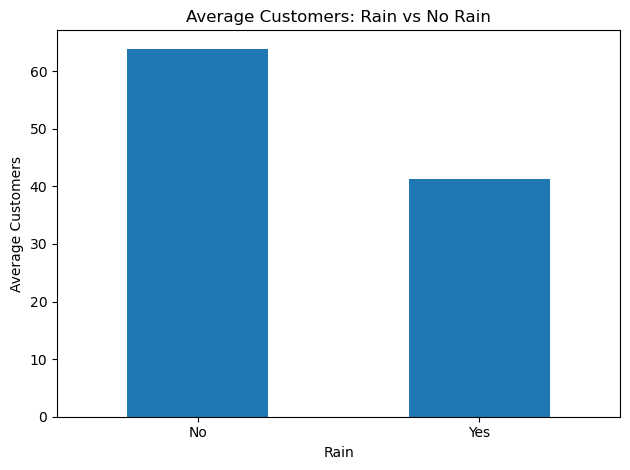

In [9]:
# Compare average customers on rainy and non-rainy mornings
rain_summary = df.groupby("Rain")["Customers"].mean()
print(rain_summary)
rain_summary.plot(kind="bar")
plt.title("Average Customers: Rain vs No Rain")
plt.xlabel("Rain")
plt.ylabel("Average Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

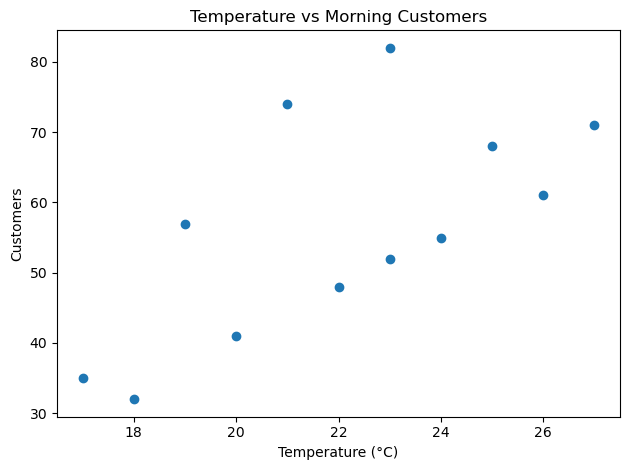

In [16]:
# Scatter plot: temperature vs customers
plt.scatter(df["Temp"], df["Customers"])
plt.title("Temperature vs Morning Customers")
plt.xlabel("Temperature (°C)")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

In [17]:
# Select the predictors and target
X = df[["Day", "Rain", "Temp", "Holiday"]]
y = df["Customers"]
print("X:")
print(X.head())
print()
print("y:")
print(y.head())

X:
   Day Rain  Temp Holiday
0  Mon   No    22      No
1  Tue   No    24      No
2  Wed  Yes    18      No
3  Thu   No    26      No
4  Fri   No    25      No

y:
0    48
1    55
2    32
3    61
4    68
Name: Customers, dtype: int64


In [18]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.25,
random_state=42
)
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 9
Testing observations: 3


In [19]:
# Identify categorical and numerical columns
categorical_features = ["Day", "Rain", "Holiday"]
numeric_features = ["Temp"]
# One-hot encode categorical variables
preprocessor = ColumnTransformer(
transformers=[
("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
("num", "passthrough", numeric_features)
]
)
# Create a pipeline: preprocessing + linear regression
model = Pipeline(
steps=[
("preprocessor", preprocessor),
("regression", LinearRegression())
]
)
# Train the model
model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [20]:
# Make predictions on the test data
y_pred = model.predict(X_test)
# Evaluate the predictions
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Actual values:")
print(y_test.to_numpy())
print()
print("Predicted values:")
print(y_pred.round(1))
print()
print("Mean Absolute Error:", round(mae, 2))
print("R-squared:", round(r2, 2))

Actual values:
[41 52 48]

Predicted values:
[40.1 51.4 54.4]

Mean Absolute Error: 2.65
R-squared: 0.31


In [31]:
# Predict customers for a new morning
new_morning = pd.DataFrame({
"Day": ["Mon"],
"Rain": ["No"],
"Temp": [10],
"Holiday": ["Yes"]
})
prediction = model.predict(new_morning)
print("Predicted customers:", round(prediction[0], 1))

Predicted customers: 59.9


   Actual  Predicted
0      41       40.1
1      52       51.4
2      48       54.4


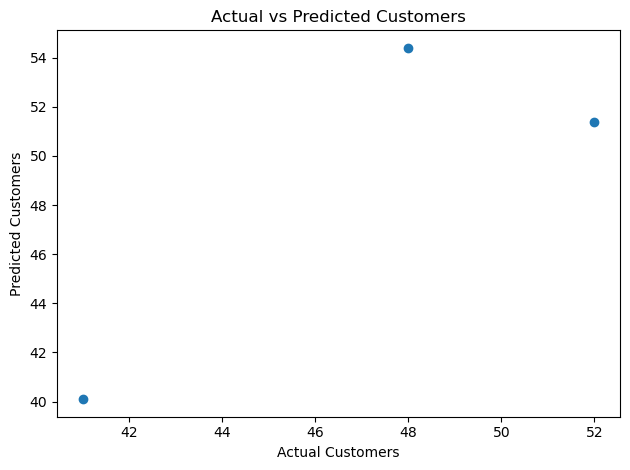

In [30]:
# Compare actual and predicted values
comparison = pd.DataFrame({
"Actual": y_test.to_numpy(),
"Predicted": y_pred.round(1)
})
print(comparison)
plt.scatter(comparison["Actual"], comparison["Predicted"])
plt.xlabel("Actual Customers")
plt.ylabel("Predicted Customers")
plt.title("Actual vs Predicted Customers")
plt.tight_layout()
plt.show()

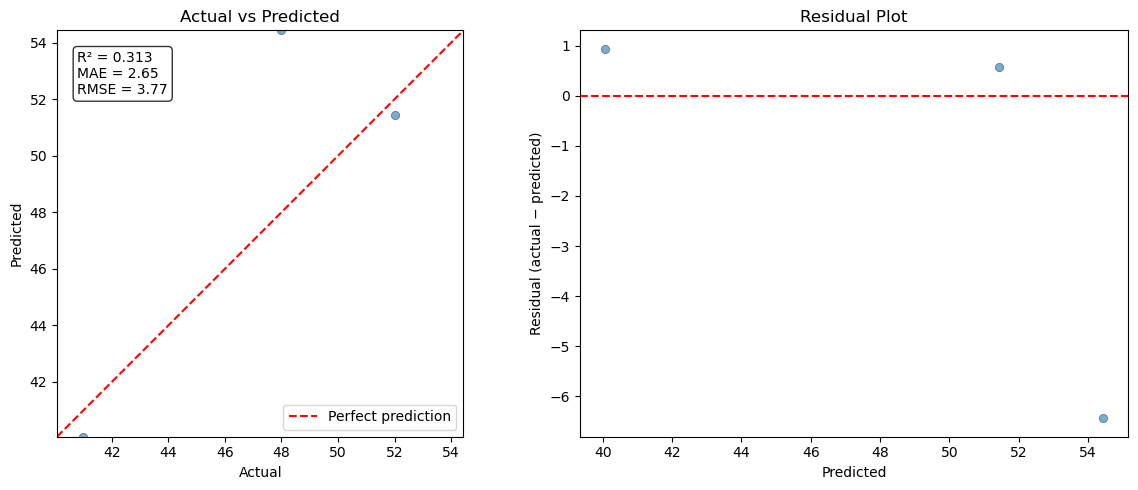

In [32]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: actual vs predicted with 45° reference line ---
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.6, edgecolor='k', linewidth=0.4)

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect('equal')

ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.set_title('Actual vs Predicted')
ax.legend()

# annotate fit quality
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
ax.text(0.05, 0.95, f'R² = {r2:.3f}\nMAE = {mae:.2f}\nRMSE = {rmse:.2f}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', fc='white', alpha=0.8))

# --- Right: residuals, which show bias the scatter hides ---
resid = y_test - y_pred
ax = axes[1]
ax.scatter(y_pred, resid, alpha=0.6, edgecolor='k', linewidth=0.4)
ax.axhline(0, color='r', ls='--', lw=1.5)
ax.set_xlabel('Predicted'); ax.set_ylabel('Residual (actual − predicted)')
ax.set_title('Residual Plot')

plt.tight_layout()
plt.show()

            Temp  Customers
count  12.000000  12.000000
mean   22.083333  56.333333
std     3.175426  15.715270
min    17.000000  32.000000
25%    19.750000  46.250000
50%    22.500000  56.000000
75%    24.250000  68.750000
max    27.000000  82.000000
Day          0
Rain         0
Temp         0
Holiday      0
Customers    0
dtype: int64


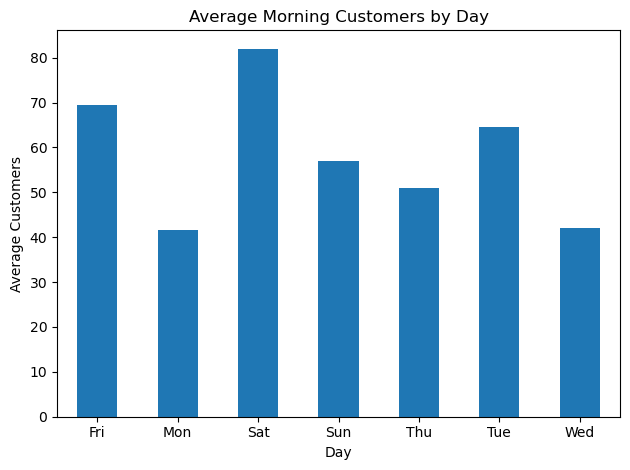

MAE: 2.65
R-squared: 0.31
Predicted customers: 85.0


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
# 1. Obtain data
data = {
"Day": ["Mon","Tue","Wed","Thu","Fri","Sat","Sun","Mon","Tue","Wed","Thu","Fri"],
"Rain": ["No","No","Yes","No","No","No","Yes","Yes","No","No","Yes","No"],
"Temp": [22,24,18,26,25,23,19,17,21,23,20,27],
"Holiday": ["No","No","No","No","No","No","No","No","Yes","No","No","No"],
"Customers": [48,55,32,61,68,82,57,35,74,52,41,71]
}
df = pd.DataFrame(data)
# 2. Explore
print(df.describe())
print(df.isnull().sum())
df.groupby("Day")["Customers"].mean().plot(kind="bar")
plt.title("Average Morning Customers by Day")
plt.ylabel("Average Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# 3. Prepare data
X = df[["Day","Rain","Temp","Holiday"]]
y = df["Customers"]
# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.25, random_state=42
)
# 5. Build model
preprocessor = ColumnTransformer(
transformers=[
("cat", OneHotEncoder(handle_unknown="ignore"),
["Day","Rain","Holiday"]),
("num", "passthrough", ["Temp"])
]
)
model = Pipeline([
("preprocessor", preprocessor),
("regression", LinearRegression())
])
model.fit(X_train, y_train)
# 6. Evaluate
y_pred = model.predict(X_test)
print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("R-squared:", round(r2_score(y_test, y_pred), 2))
# 7. Predict a new morning
new_morning = pd.DataFrame({
"Day": ["Sat"],
"Rain": ["No"],
"Temp": [25],
"Holiday": ["No"]
})
prediction = model.predict(new_morning)
print("Predicted customers:", round(prediction[0], 1))